In [1]:
import catppuccin
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

In [2]:
matplotlib.style.use(["dark_background", catppuccin.PALETTE.mocha.identifier])
%matplotlib inline


In [3]:
df = pd.read_csv("./datasets/bank_churn.csv")
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [4]:
df.shape

(10000, 14)

In [5]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [7]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [8]:
df.drop(columns=["RowNumber", "CustomerId", "Surname"], inplace=True)
df.drop_duplicates(inplace=True)
df

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...
9995,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [9]:
for col in df.select_dtypes(include=["object"]).columns:
    print(f"{col:<15}{df[col].unique()}")

Geography      ['France' 'Spain' 'Germany']
Gender         ['Female' 'Male']


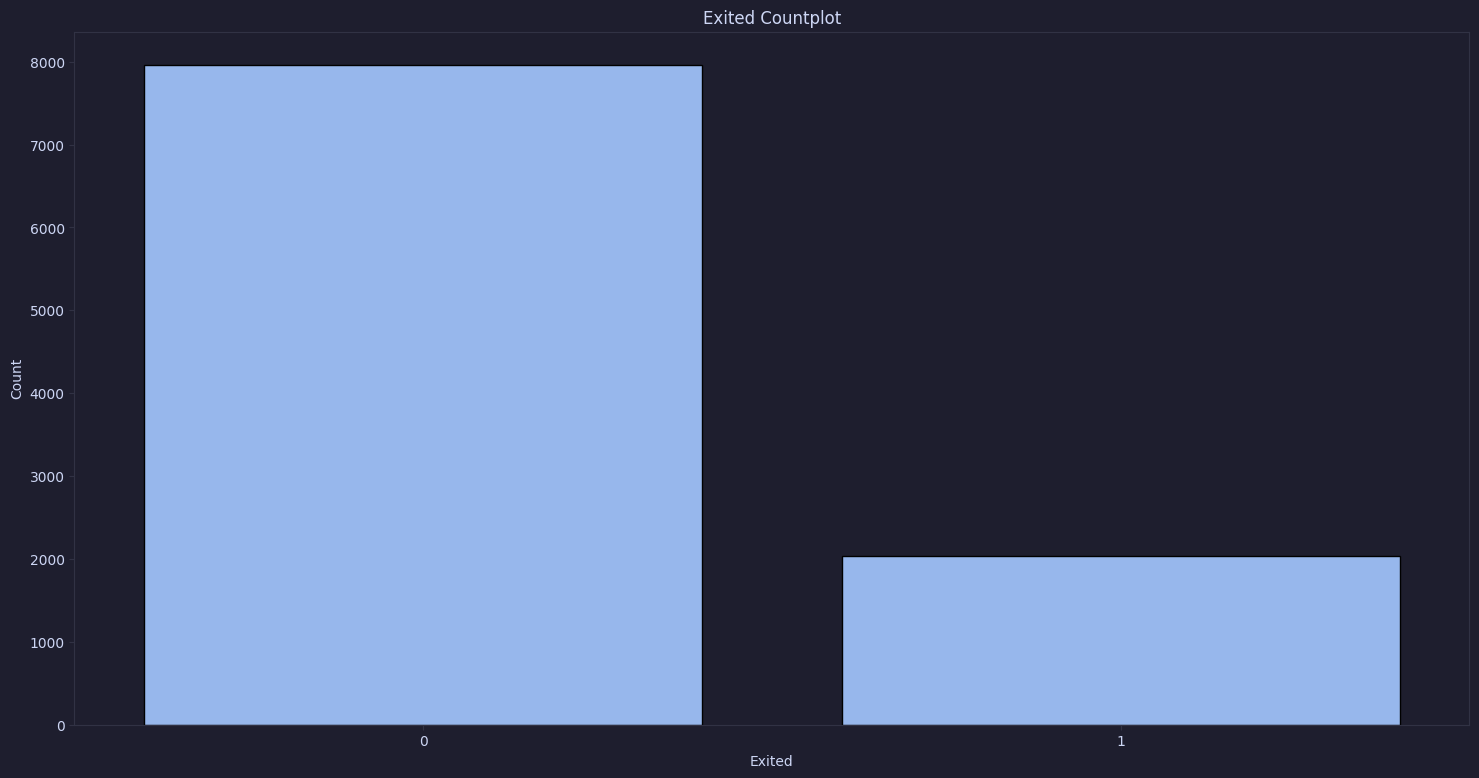

In [10]:
plt.figure(figsize=(18, 9))

sns.countplot(data=df, x="Exited", edgecolor="black")
plt.title("Exited Countplot")
plt.xlabel("Exited")
plt.ylabel("Count")
plt.show()


In [11]:
cat_cols = ["Gender", "HasCrCard", "IsActiveMember", "NumOfProducts", "Tenure"]

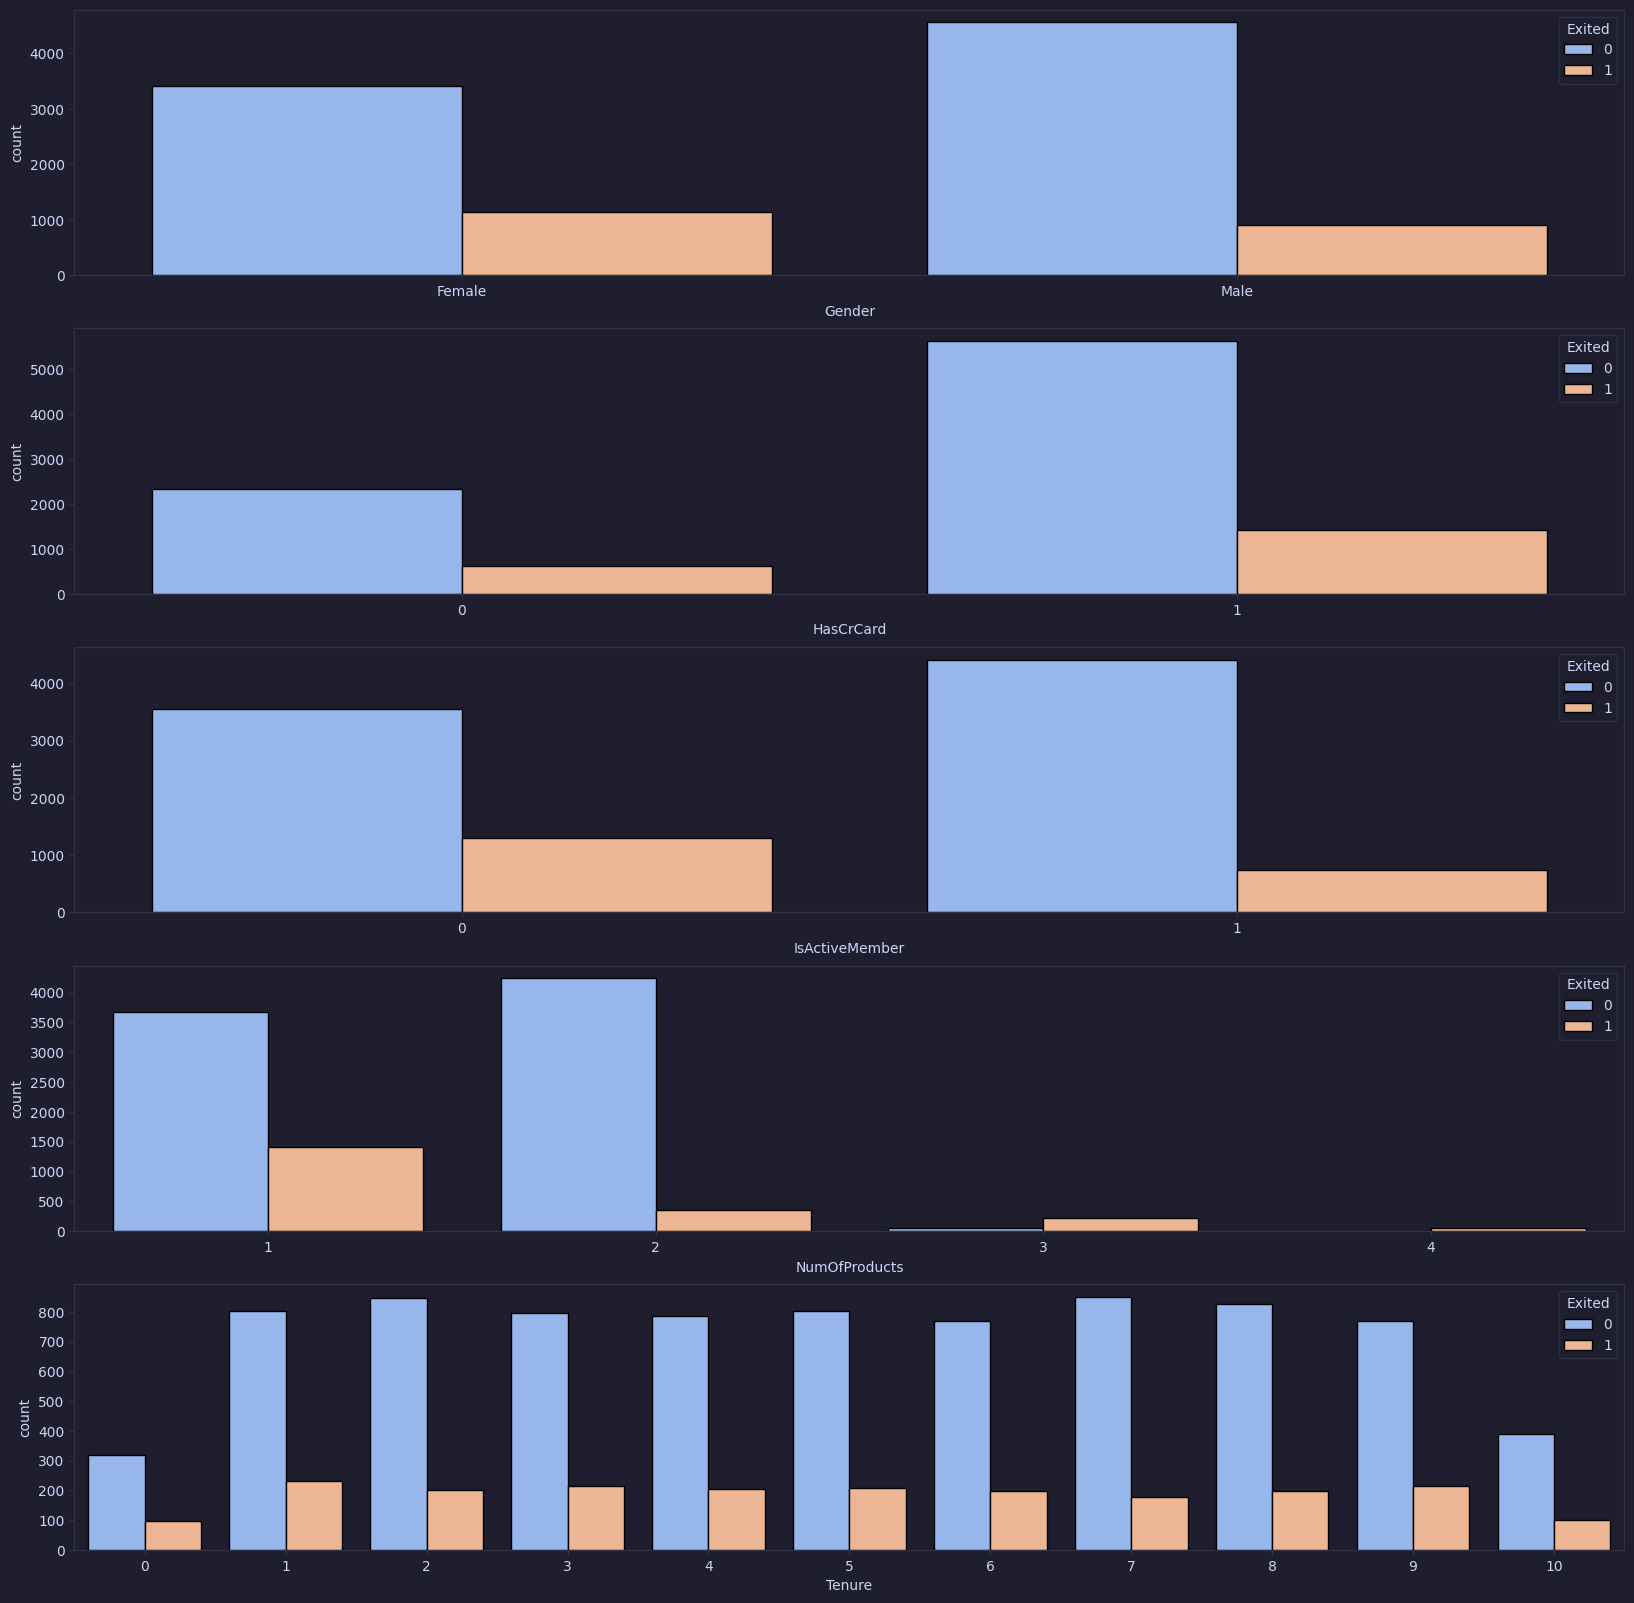

In [12]:
fig, axes = plt.subplots(5, 1, figsize=(20, 20))
axes = axes.flatten()

for col, ax in zip(cat_cols, axes):
    sns.countplot(data=df, x=col, hue="Exited", ax=ax, edgecolor="black")

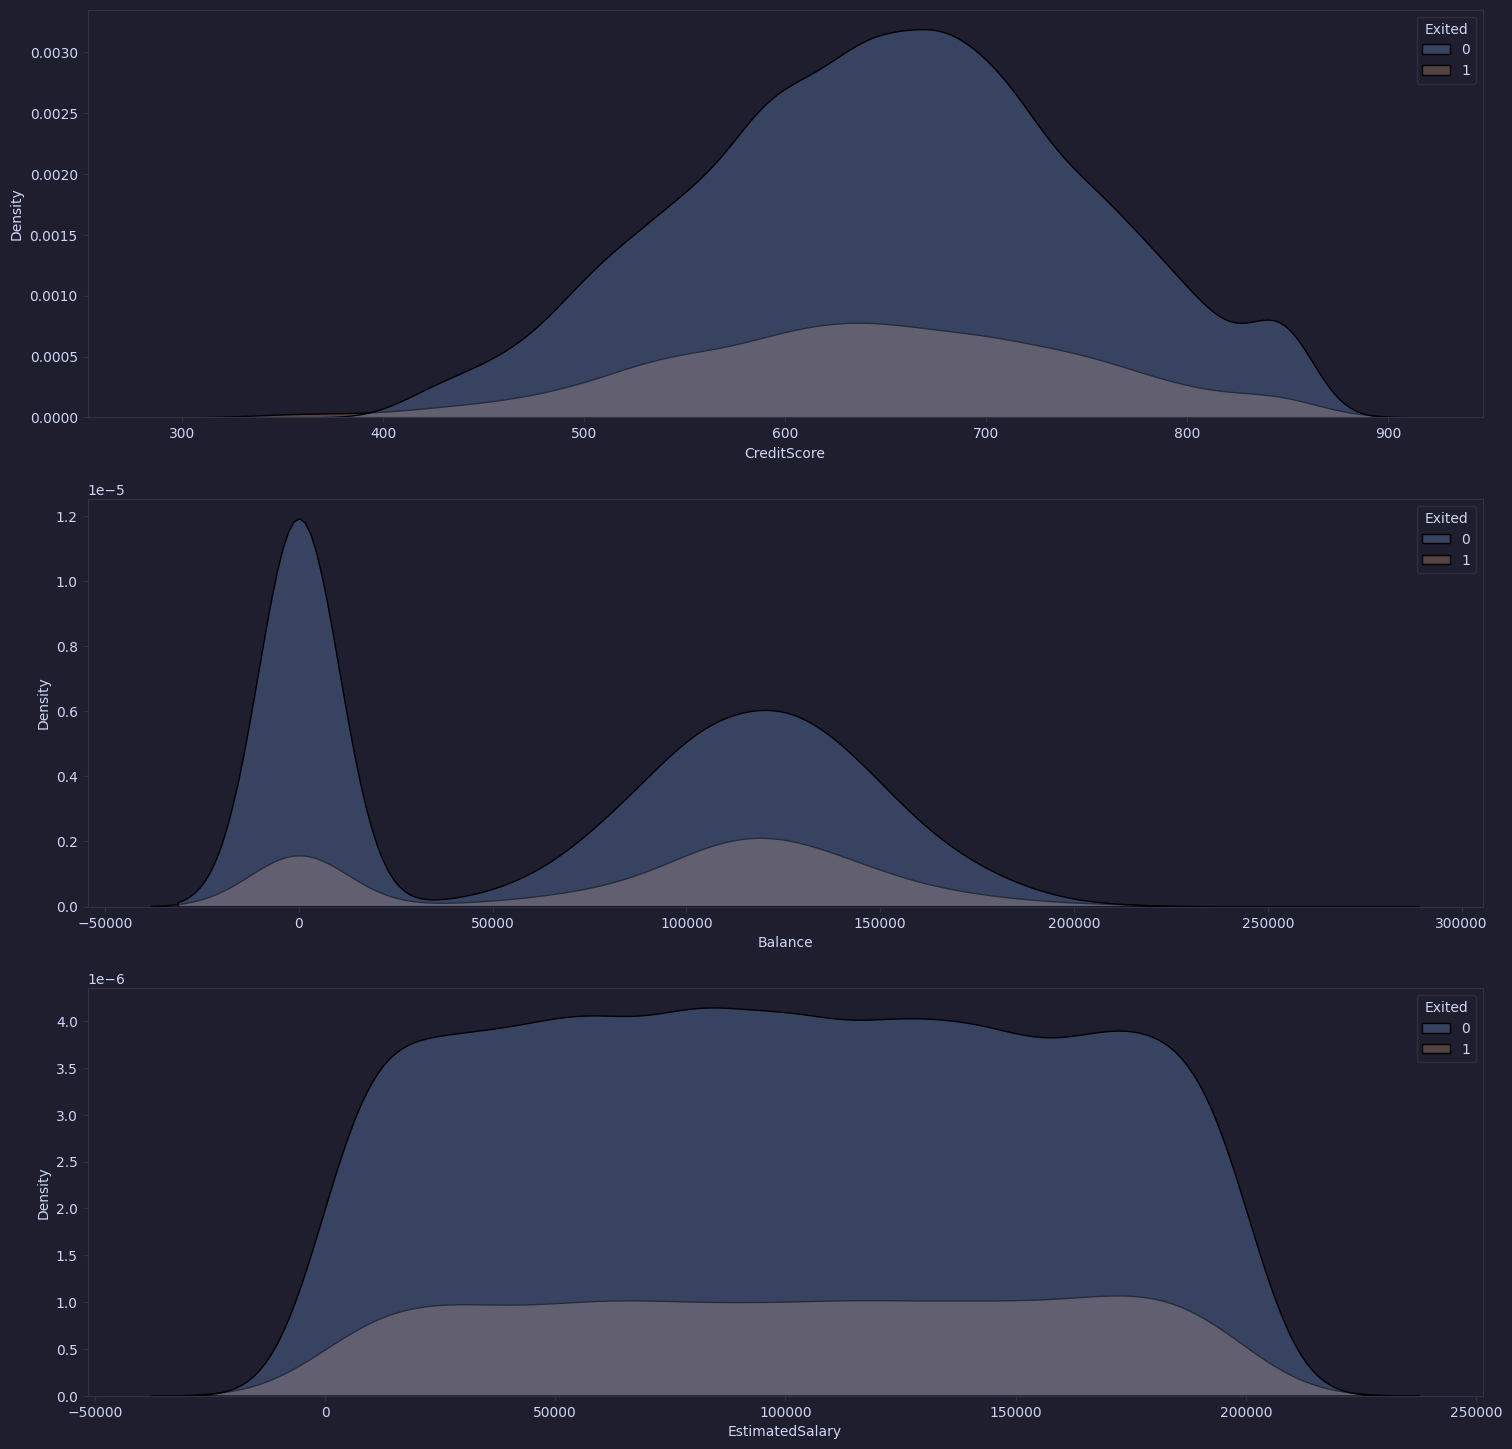

In [13]:
fig, axes = plt.subplots(3, 1, figsize=(18, 18))
axes = axes.flatten()
kde_cols = ["CreditScore", "Balance", "EstimatedSalary"]
for ax, col in zip(axes, kde_cols):
    sns.kdeplot(data=df, x=col, hue="Exited", edgecolor="black", fill=True, ax=ax)


In [14]:
df["Gender"] = df["Gender"].map({"Female": 0, "Male": 1}).astype(int)
df = pd.get_dummies(df, columns=["Geography"], dtype=int)
df = pd.concat([df.drop(columns=["Exited"]), df["Exited"]], axis=1)
df


,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Exited
0,619,0,42,2,0.00,1,1,1,101348.88,1,0,0,1
1,608,0,41,1,83807.86,1,0,1,112542.58,0,0,1,0
2,502,0,42,8,159660.80,3,1,0,113931.57,1,0,0,1
3,699,0,39,1,0.00,2,0,0,93826.63,1,0,0,0
4,850,0,43,2,125510.82,1,1,1,79084.10,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,771,1,39,5,0.00,2,1,0,96270.64,1,0,0,0
9996,516,1,35,10,57369.61,1,1,1,101699.77,1,0,0,0
9997,709,0,36,7,0.00,1,0,1,42085.58,1,0,0,1
9998,772,1,42,3,75075.31,2,1,0,92888.52,0,1,0,1


In [15]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df = pd.DataFrame(scaler.fit_transform(df), columns=scaler.get_feature_names_out())
df

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain,Exited
0,0.538,0.0,0.324324,0.2,0.000000,0.000000,1.0,1.0,0.506735,1.0,0.0,0.0,1.0
1,0.516,0.0,0.310811,0.1,0.334031,0.000000,0.0,1.0,0.562709,0.0,0.0,1.0,0.0
2,0.304,0.0,0.324324,0.8,0.636357,0.666667,1.0,0.0,0.569654,1.0,0.0,0.0,1.0
3,0.698,0.0,0.283784,0.1,0.000000,0.333333,0.0,0.0,0.469120,1.0,0.0,0.0,0.0
4,1.000,0.0,0.337838,0.2,0.500246,0.000000,1.0,1.0,0.395400,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,0.842,1.0,0.283784,0.5,0.000000,0.333333,1.0,0.0,0.481341,1.0,0.0,0.0,0.0
9996,0.332,1.0,0.229730,1.0,0.228657,0.000000,1.0,1.0,0.508490,1.0,0.0,0.0,0.0
9997,0.718,0.0,0.243243,0.7,0.000000,0.000000,0.0,1.0,0.210390,1.0,0.0,0.0,1.0
9998,0.844,1.0,0.324324,0.3,0.299226,0.333333,1.0,0.0,0.464429,0.0,1.0,0.0,1.0


In [16]:
X = df.drop(columns=["Exited"], axis=1)
y = df["Exited"]

In [17]:
from imblearn.over_sampling import SMOTEN
from collections import Counter

smoten = SMOTEN(sampling_strategy="minority", random_state=42)
print(f"Before resampling: {Counter(y)}")
X, y = smoten.fit_resample(X, y)
print(f"After resampling: {Counter(y)}")

Before resampling: Counter({0.0: 7963, 1.0: 2037})
After resampling: Counter({1.0: 7963, 0.0: 7963})


In [18]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [19]:
model = keras.Sequential(
    [
        keras.Input(shape=(X_train.shape[1],)),
        keras.layers.Dense(200, activation="relu"),
        keras.layers.Dense(100, activation="relu"),
        keras.layers.Dense(50, activation="relu"),
        keras.layers.Dense(10, activation="relu"),
        keras.layers.Dense(1, activation="sigmoid"),
    ]
)

In [20]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [21]:
model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.7740 - loss: 0.4930 - val_accuracy: 0.8089 - val_loss: 0.4274
Epoch 2/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 910us/step - accuracy: 0.8367 - loss: 0.3818 - val_accuracy: 0.8371 - val_loss: 0.3832
Epoch 3/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 610us/step - accuracy: 0.8436 - loss: 0.3633 - val_accuracy: 0.8311 - val_loss: 0.3765
Epoch 4/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 602us/step - accuracy: 0.8520 - loss: 0.3494 - val_accuracy: 0.8487 - val_loss: 0.3591
Epoch 5/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 616us/step - accuracy: 0.8535 - loss: 0.3389 - val_accuracy: 0.8519 - val_loss: 0.3391
Epoch 6/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 599us/step - accuracy: 0.8617 - loss: 0.3276 - val_accuracy: 0.8481 - val_loss: 0.3508
Epoch 7/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 612us/step - accuracy: 0.8645 - loss: 0.3205 - val_accuracy: 0.8569 - val_loss: 0.3340
Epoch 8/100
399/399 ━━━━━━━━━━━━━━━━━━━━ 0s 601us/step - accuracy: 0.8692 - loss: 0

In [22]:
model.evaluate(X_test, y_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 398us/step - accuracy: 0.8616 - loss: 0.6919


[0.6919194459915161, 0.8615819215774536]

In [23]:
y_hat = model.predict(X_test)

100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 850us/step


In [24]:
y_hat = [0 if y < 0.5 else 1 for y in y_hat]
y_hat[:10]

[0, 1, 0, 0, 0, 0, 1, 1, 1, 1]

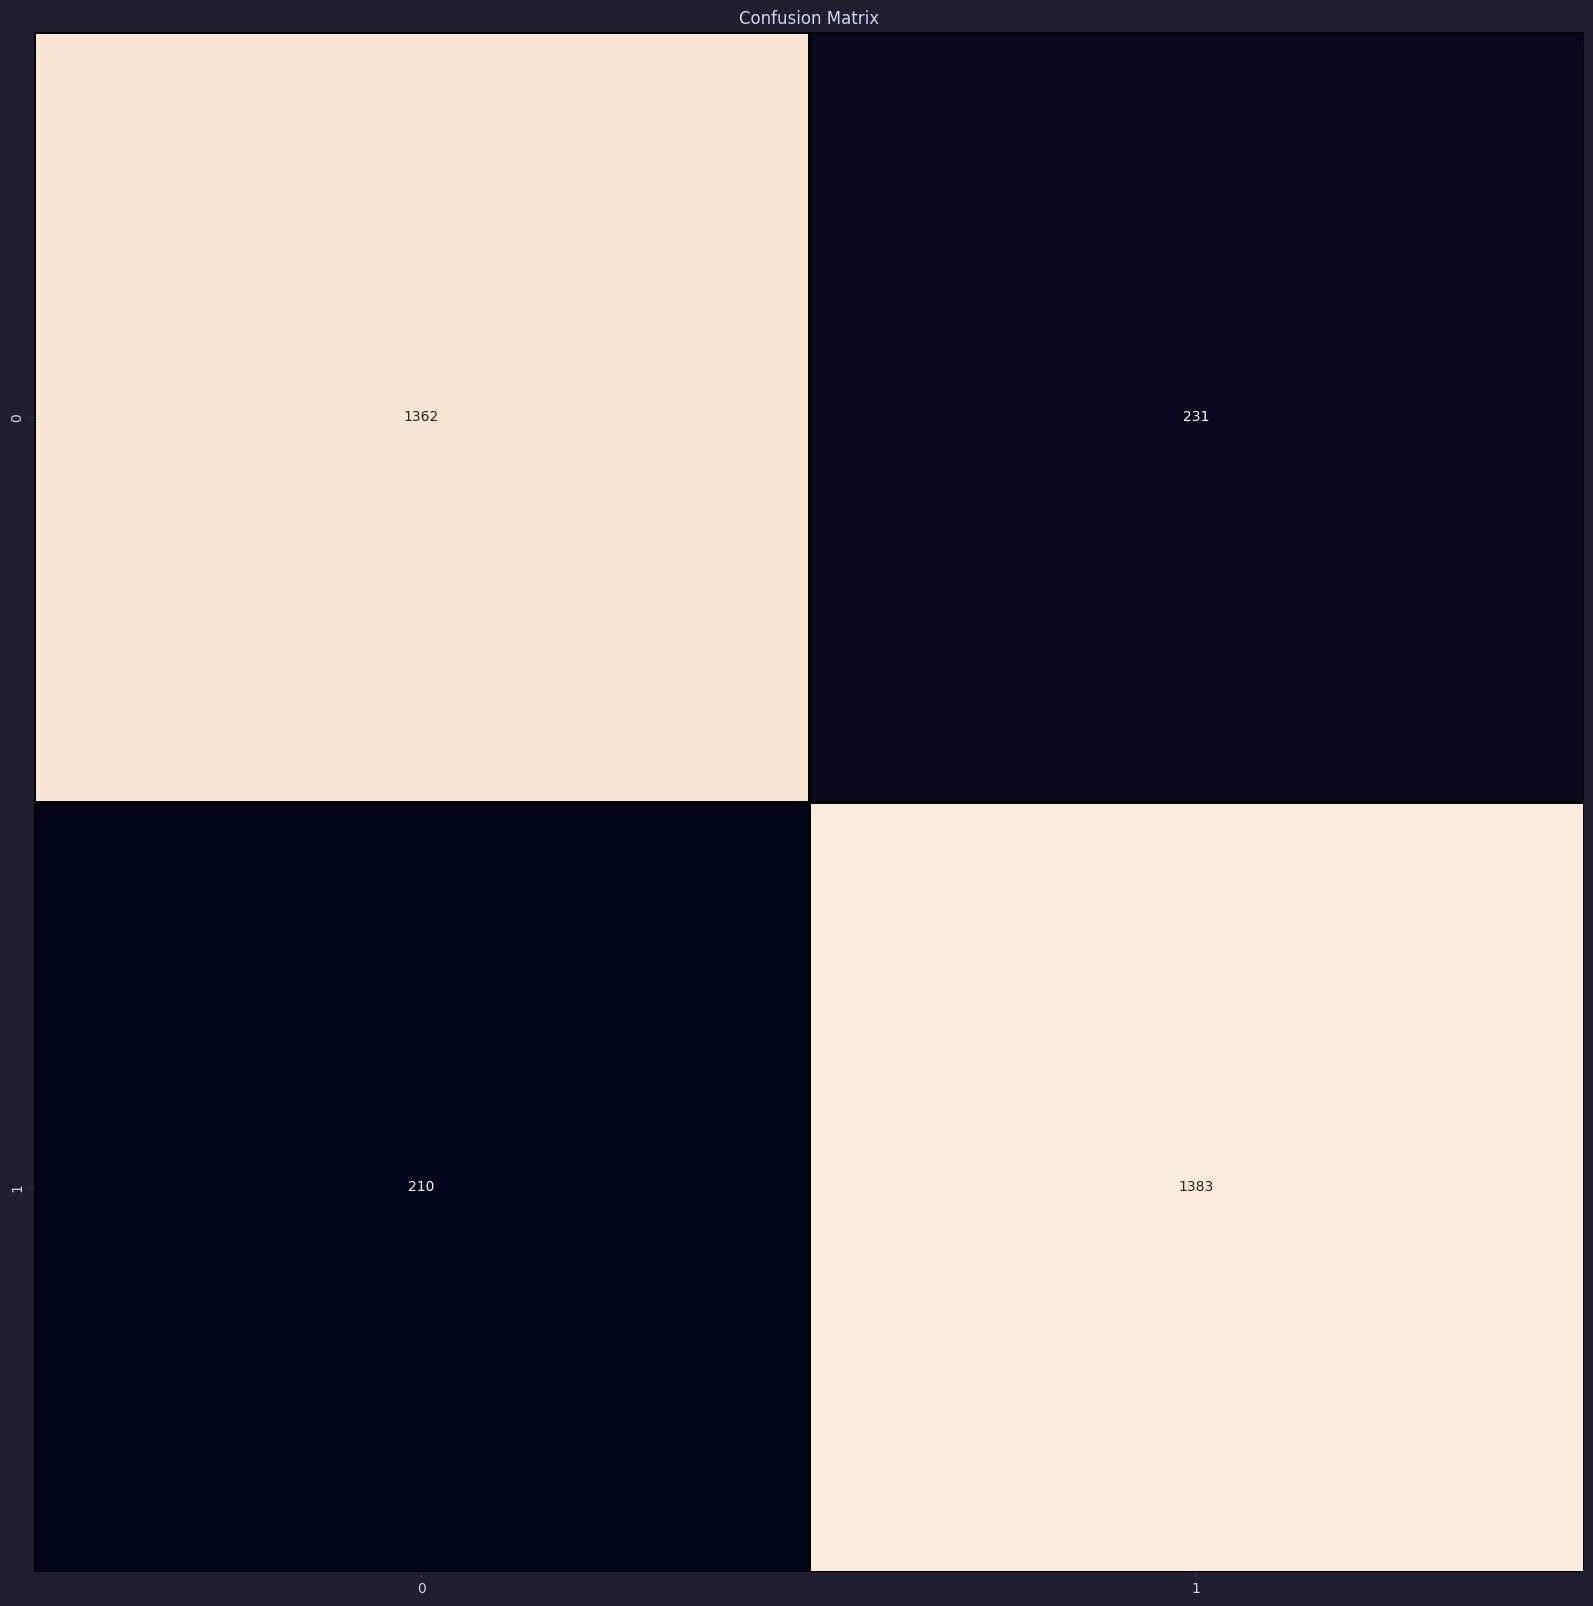

In [25]:
from sklearn.metrics import confusion_matrix, classification_report

cm = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(20, 20))

sns.heatmap(data=cm, cbar=False, annot=True, fmt="d", linecolor="black", linewidths=1)
plt.title("Confusion Matrix")
plt.show()

In [26]:
print(classification_report(y_test, y_hat))

              precision    recall  f1-score   support

         0.0       0.87      0.85      0.86      1593
         1.0       0.86      0.87      0.86      1593

    accuracy                           0.86      3186
   macro avg       0.86      0.86      0.86      3186
weighted avg       0.86      0.86      0.86      3186

